<a href="https://colab.research.google.com/github/kennedy-harris/mis433/blob/main/Vibe_coding_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import requests
from google.colab import userdata

# Define the base URL for TheDogAPI breeds search
BASE_URL = "https://api.thedogapi.com/v1/breeds/search?q="

def get_breed_info_from_api(breed_name, api_key):
    """
    Fetches information for a single dog breed from TheDogAPI using an API key.

    Args:
        breed_name (str): The name of the dog breed to search for.
        api_key (str): The API key for authentication (optional for search, but included).

    Returns:
        dict or None: A dictionary containing the breed's information if found,
                      otherwise None.
    """
    # For TheDogAPI search, the breed name is appended directly to the base URL
    endpoint = f"{BASE_URL}{breed_name}"

    # Add the API key to the request headers (TheDogAPI uses this for other endpoints,
    # but it doesn't hurt for search and could be necessary for other interactions later).
    headers = {
        "x-api-key": api_key
    }

    try:
        response = requests.get(endpoint, headers=headers)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        data = response.json()  # This will be a list of dictionaries for TheDogAPI

        if data: # If the list of results is not empty
            # TheDogAPI returns a list of breed objects. We look for an exact name match.
            for breed_data in data:
                if breed_data.get('name') and breed_data['name'].lower() == breed_name.lower():
                    return breed_data  # Return the entire breed dictionary
            print(f"No exact match found for breed: {breed_name}. Found: {[b.get('name') for b in data if b.get('name')]}")
            return None
        else:
            print(f"No information found for breed: {breed_name}")
            return None

    except requests.exceptions.RequestException as e:
        print(f"Error fetching information for {breed_name}: {e}")
        print("Please ensure your API key is correct and valid, and you have an internet connection.")
        return None
    except ValueError as e: # Catch JSON decoding errors
        print(f"Error decoding JSON response for breed: {breed_name}: {e}")
        return None

def main():
    # Get the API key from Colab secrets
    # Make sure you have added 'DOG_API' to your Colab secrets
    try:
        dog_api_key = userdata.get('DOG_API')
    except userdata.SecretNotFoundError:
        print("Error: 'DOG_API' secret not found. Please add your Dog API key to Colab secrets.")
        return

    # Prompt the user for a dog breed
    breed_input = input("Enter a dog breed name to find information (e.g., Poodle, German Shepherd): ")
    if not breed_input.strip():
        print("Breed name cannot be empty.")
        return

    print(f"\nSearching for information on: {breed_input.title()}...")
    breed_info = get_breed_info_from_api(breed_input.strip(), dog_api_key)

    if breed_info:
        print(f"\n--- Information for {breed_info.get('name', 'Unknown Breed')} ---")
        for key, value in breed_info.items():
            # Handle nested dictionaries like 'weight' and 'height' for better display
            if isinstance(value, dict):
                print(f"  {key.replace('_', ' ').title()}:")
                for sub_key, sub_value in value.items():
                    print(f"    {sub_key.replace('_', ' ').title()}: {sub_value}")
            else:
                print(f"  {key.replace('_', ' ').title()}: {value}")
    else:
        print(f"Could not retrieve detailed information for {breed_input.title()}. Please check the breed name.")

# Run the main function
main()

Enter a dog breed name to find information (e.g., Poodle, German Shepherd): German Shepherd

Searching for information on: German Shepherd...

--- Information for German Shepherd ---
  Id: 115
  Name: German Shepherd
  Species Id: 2
  Life Span: 9-13
  Temperament: Confident, courageous, intelligent, loyal, protective
  Origin: Germany
  Country Codes: DE
  Country Code: DE
  Description: Large, athletic working dog with erect ears, noble expression, and confident bearing. Known for high intelligence, loyalty, courage, and versatility in herding and working roles.
  Bred For: None
  Perfect For: None
  Breed Group: Herding
  History: Developed in 1899 by Captain Max von Stephanitz to create the ideal herding dog, standardized from local shepherd dogs. Intelligence and trainability led to worldwide use in police and military roles.
  Reference Image Id: None
  Weight:
    Imperial: Male: 65-90; Female: 50-70
    Metric: Male: 29-41; Female: 23-32
  Height:
    Imperial: Male: 24-26; Fem

In [9]:
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY')

In [10]:
from openai import OpenAI

# If you have set OPENAI_API_KEY properly
client = OpenAI(api_key=api_key)

In [11]:
import requests
from google.colab import userdata
from openai import OpenAI

# Re-defining BASE_URL and get_breed_info_from_api for self-containment
# This ensures the function works even if previous cells are re-ordered or deleted.
BASE_URL = "https://api.thedogapi.com/v1/breeds/search?q="

def get_breed_info_from_api(breed_name, api_key):
    """
    Fetches information for a single dog breed from TheDogAPI using an API key.

    Args:
        breed_name (str): The name of the dog breed to search for.
        api_key (str): The API key for authentication (optional for search, but included).

    Returns:
        dict or None: A dictionary containing the breed's information if found,
                      otherwise None.
    """
    endpoint = f"{BASE_URL}{breed_name}"
    headers = {
        "x-api-key": api_key
    }

    try:
        response = requests.get(endpoint, headers=headers)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        data = response.json()

        if data:
            for breed_data in data:
                if breed_data.get('name') and breed_data['name'].lower() == breed_name.lower():
                    return breed_data
            print(f"No exact match found for breed: {breed_name}. Found: {[b.get('name') for b in data if b.get('name')]}")
            return None
        else:
            print(f"No information found for breed: {breed_name}")
            return None

    except requests.exceptions.RequestException as e:
        print(f"Error fetching information for {breed_name}: {e}")
        print("Please ensure your API key is correct and valid, and you have an internet connection.")
        return None
    except ValueError as e:
        print(f"Error decoding JSON response for breed: {breed_name}: {e}")
        return None

def generate_crossbreed_description_and_info_openai():
    """
    Prompts the user for two dog breeds, retrieves their info using TheDogAPI,
    and uses OpenAI to generate a description of their hypothetical crossbreed.
    """
    try:
        dog_api_key = userdata.get('DOG_API')
        openai_api_key = userdata.get('OPENAI_API_KEY')
    except userdata.SecretNotFoundError as e:
        print(f"Error: {e}. Please ensure both 'DOG_API' and 'OPENAI_API_KEY' are added to Colab secrets.")
        return

    # Initialize OpenAI client
    openai_client = OpenAI(api_key=openai_api_key)

    # Get first breed input
    breed1_input = input("Enter the FIRST dog breed name (e.g., Golden Retriever): ")
    if not breed1_input.strip():
        print("First breed name cannot be empty.")
        return

    # Get second breed input
    breed2_input = input("Enter the SECOND dog breed name (e.g., Poodle): ")
    if not breed2_input.strip():
        print("Second breed name cannot be empty.")
        return

    print(f"\nSearching for information on: {breed1_input.title()} and {breed2_input.title()}...\n")

    # Retrieve information for both breeds
    breed1_info = get_breed_info_from_api(breed1_input.strip(), dog_api_key)
    breed2_info = get_breed_info_from_api(breed2_input.strip(), dog_api_key)

    if not breed1_info:
        print(f"Could not find information for {breed1_input.title()}. Please check the spelling.")
        return
    if not breed2_info:
        print(f"Could not find information for {breed2_input.title()}. Please check the spelling.")
        return

    # Display information for the first breed
    print(f"\n--- Information for {breed1_info.get('name', 'Unknown Breed 1')} ---")
    for key, value in breed1_info.items():
        if isinstance(value, dict):
            print(f"  {key.replace('_', ' ').title()}:")
            for sub_key, sub_value in value.items():
                print(f"    {sub_key.replace('_', ' ').title()}: {sub_value}")
        else:
            print(f"  {key.replace('_', ' ').title()}: {value}")

    # Display information for the second breed
    print(f"\n--- Information for {breed2_info.get('name', 'Unknown Breed 2')} ---")
    for key, value in breed2_info.items():
        if isinstance(value, dict):
            print(f"  {key.replace('_', ' ').title()}:")
            for sub_key, sub_value in value.items():
                print(f"    {sub_key.replace('_', ' ').title()}: {sub_value}")
        else:
            print(f"  {key.replace('_', ' ').title()}: {value}")

    # --- Generate Crossbreed Description using OpenAI API --- #
    print("\n--- Generating Crossbreed Description (powered by OpenAI) ---")
    try:
        system_message = "You are an expert dog breeder and genetics specialist, able to create realistic descriptions of hypothetical dog crossbreeds."

        user_prompt = f"Given two dog breeds, {breed1_info.get('name')} and {breed2_info.get('name')}, describe what a hypothetical crossbreed between them would be like. Consider their typical temperament, physical characteristics (size, coat, build), and any unique traits. \n\n"
        user_prompt += f"Breed 1: {breed1_info.get('name')}. Temperament: {breed1_info.get('temperament', 'N/A')}. Description: {breed1_info.get('description', 'N/A')}. Life Span: {breed1_info.get('life_span', 'N/A')}. Weight (Imperial): {breed1_info.get('weight', {}).get('imperial', 'N/A')}. Height (Imperial): {breed1_info.get('height', {}).get('imperial', 'N/A')}.\n"
        user_prompt += f"Breed 2: {breed2_info.get('name')}. Temperament: {breed2_info.get('temperament', 'N/A')}. Description: {breed2_info.get('description', 'N/A')}. Life Span: {breed2_info.get('life_span', 'N/A')}. Weight (Imperial): {breed2_info.get('weight', {}).get('imperial', 'N/A')}. Height (Imperial): {breed2_info.get('height', {}).get('imperial', 'N/A')}.\n\n"
        user_prompt += "Describe the crossbreed in detail, covering its potential appearance, personality, and care requirements."

        response = openai_client.chat.completions.create(
            model="gpt-3.5-turbo", # You can choose other models like "gpt-4" if available and preferred
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": user_prompt}
            ]
        )

        if response.choices:
            print(response.choices[0].message.content)
        else:
            print("OpenAI could not generate a description.")

    except Exception as e:
        print(f"An error occurred while generating the AI description: {e}")
        print("Please ensure your OpenAI API key is correct and valid, and you have access to the model.")

# Run the function
generate_crossbreed_description_and_info_openai()


Enter the FIRST dog breed name (e.g., Golden Retriever): Great Dane
Enter the SECOND dog breed name (e.g., Poodle): Golden Retriever

Searching for information on: Great Dane and Golden Retriever...


--- Information for Great Dane ---
  Id: 124
  Name: Great Dane
  Species Id: 2
  Life Span: 7-10
  Temperament: Friendly, gentle, confident, loyal, affectionate
  Origin: Germany
  Country Codes: DE
  Country Code: DE
  Description: Giant, regal breed known as the 'Apollo of Dogs' with a powerful, well-muscled body, sleek coat, and dignified presence combined with noble bearing despite imposing size
  Bred For: None
  Perfect For: None
  Breed Group: Working
  History: Originally bred by German nobility from Mastiff-type dogs to hunt wild boar and deer, later refined as estate guardians and companions. Declared national dog of Germany in 1876 and standardized as 'Deutsche Dogge'
  Reference Image Id: None
  Weight:
    Imperial: Male: 140-175; Female: 110-140
    Metric: Male: 64-79; Fem

In [17]:
prompt = """A crossbreed between a Great Dane and a Golden Retriever, often referred to as a Golden Dane, would inherit a fascinating combination of traits from both parent breeds.

In terms of appearance, a Golden Dane would likely be a large to giant-sized dog with a sturdy, well-proportioned build. They may have a broad head with a friendly expression, medium to large pendant ears, and deep, expressive eyes. Their coat could be dense, medium to long in length, and could come in a variety of colors such as golden, fawn, or a mix of both parental colors.

In terms of size, the Golden Dane would likely fall somewhere between the Great Dane and Golden Retriever averages, weighing around 90-140 pounds and standing at a shoulder height of 25-30 inches.

Personality-wise, the Golden Dane would inherit the friendly, loyal, and eager-to-please nature of both parent breeds. They would be highly affectionate towards their family members, including children and other pets, making them excellent family companions. Their gentle and confident demeanor would make them well-suited for households seeking a loyal and loving canine companion.

In terms of care requirements, the Golden Dane would need regular exercise to maintain their health and prevent obesity, given their size and potential for joint issues. Their coat would require regular brushing to prevent matting and to keep it looking its best. Additionally, early socialization and training would be essential to help channel their intelligence and energy in a positive direction.

Overall, the Golden Dane would be a delightful and loving crossbreed, ideal for families looking for a loyal, affectionate, and gentle giant with a friendly personality and striking appearance."""

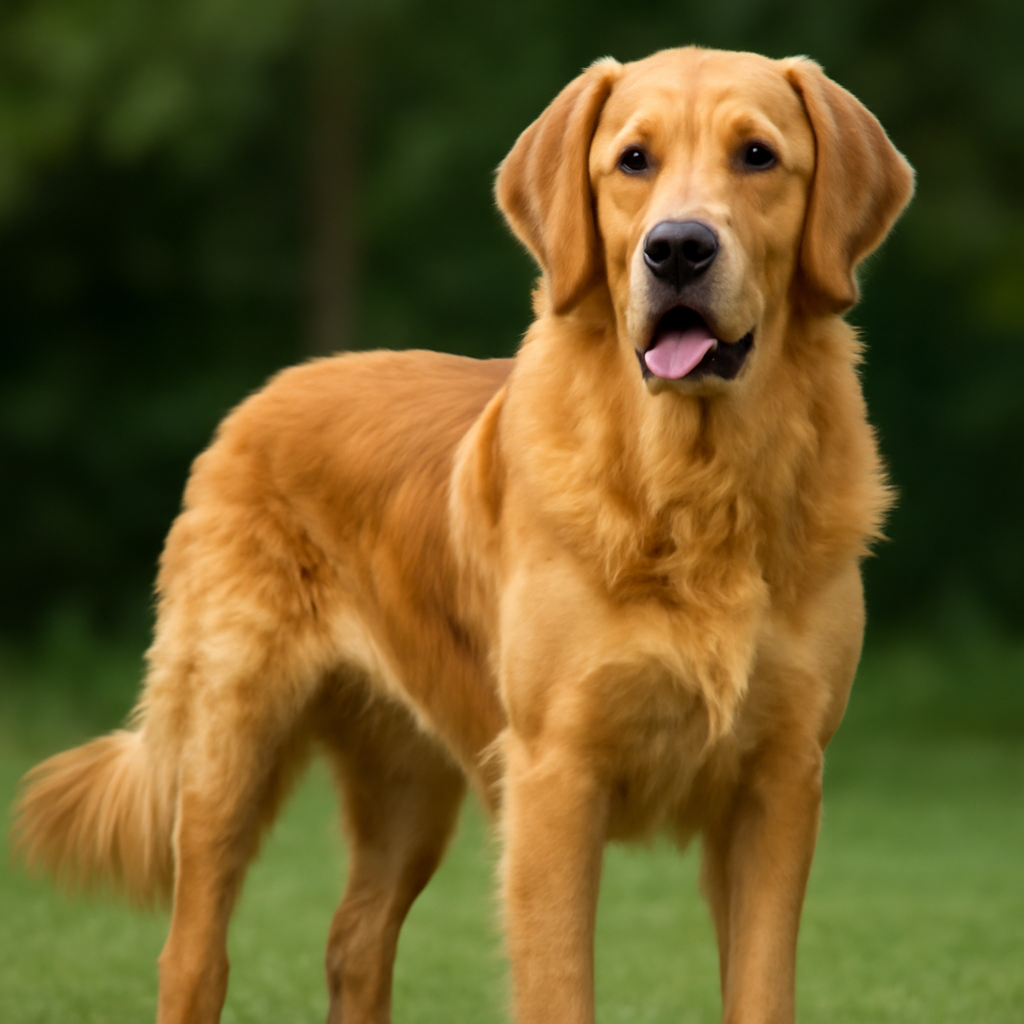

In [18]:
from IPython.display import Image, display
import base64

result = client.images.generate(
    model="gpt-image-1",
    prompt=prompt,
    size="1024x1024",
    quality="low" # change this to "medium" or "high" for better quality at a higher cost
)

image_bytes = base64.b64decode(result.data[0].b64_json)

display(Image(data=image_bytes))